# GPU and Hardware Basics: Understanding CUDA Cores and Memory Hierarchy

## 1. Introduction

Understanding how GPUs work at a hardware level is crucial for writing efficient deep learning code. In this notebook, we'll explore:

- **Why GPUs are fast** for parallel workloads like neural networks
- **What CUDA cores are** and how they differ from CPU cores
- **Memory hierarchy** in GPUs and how it affects performance
- **Practical demonstrations** showing the impact of memory access patterns

By the end, you'll understand why certain operations are fast on GPUs and how to avoid common performance pitfalls.

## 2. Setup

### Configuration

We'll define all parameters here for easy experimentation.

In [1]:
CONFIG = {
    # Reproducibility
    'seed': 42,  # Random seed for reproducibility
    
    # Benchmarking
    'num_iterations': 100,  # Number of iterations for timing
    'warmup_iterations': 10,  # Warmup iterations to stabilize timing
    
    # Matrix sizes for demonstrations
    'small_size': 1024,  # Small matrix dimension
    'medium_size': 4096,  # Medium matrix dimension
    'large_size': 8192,  # Large matrix dimension
}

### Random Seed & Device

Set up reproducibility and detect available hardware.

In [2]:
from aiml_notebooks import get_device, set_seed
import torch

%load_ext autoreload
%autoreload 2

set_seed(CONFIG['seed'])
device = get_device()

print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Cores: ~{torch.cuda.get_device_properties(0).multi_processor_count * 128} (approx)")
elif device.type == 'mps':
    print("Using Apple Silicon GPU")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda
GPU Name: NVIDIA GeForce RTX 4090
GPU Memory: 25.76 GB
CUDA Cores: ~16384 (approx)


## 3. CPU vs GPU: Different Design Philosophies

### The Fundamental Difference

Before diving into CUDA cores, let's understand why CPUs and GPUs are designed differently.

**CPUs** are designed for:
- **Latency**: Getting one task done as fast as possible
- **Complex control flow**: Branching, loops, conditionals
- **Large caches**: Store frequently accessed data close to cores
- **Few powerful cores**: 4-64 cores with sophisticated features

**GPUs** are designed for:
- **Throughput**: Getting many tasks done simultaneously
- **Simple, repetitive operations**: Same operation on different data (SIMD)
- **Smaller caches**: More silicon devoted to computation
- **Thousands of simple cores**: Massively parallel execution

### Visualizing the Architecture

Let's create a visual comparison of CPU vs GPU architecture.

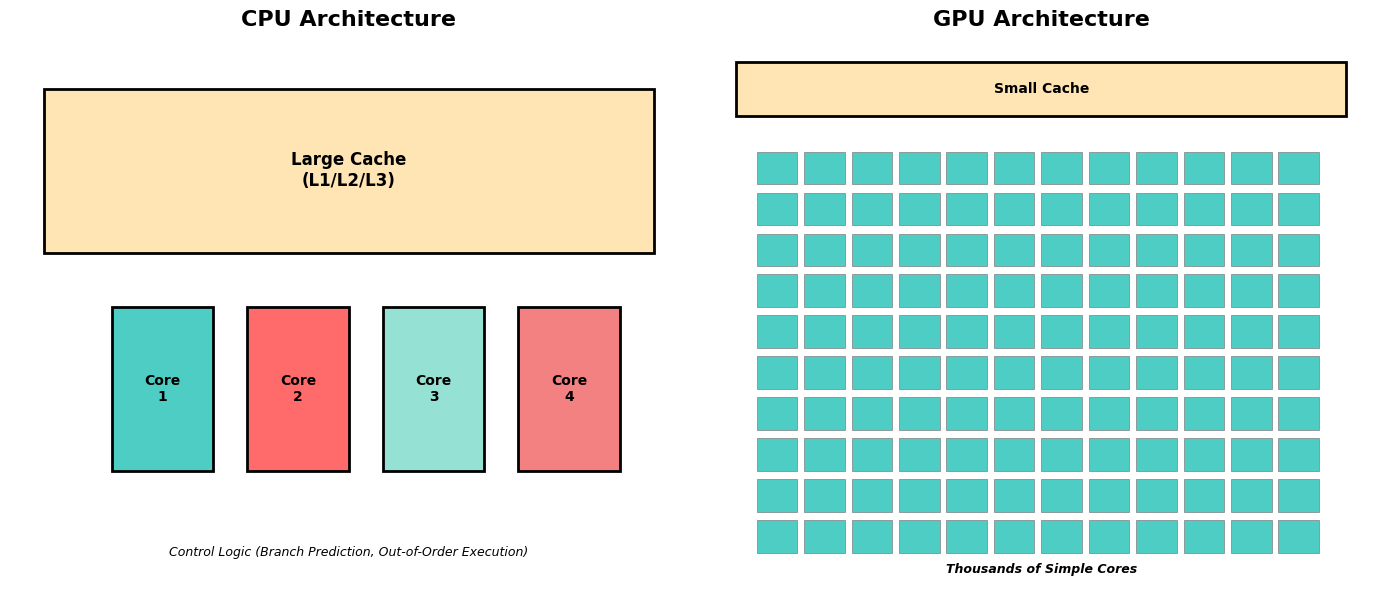


Key Insight:
CPUs: Few complex cores with large caches (latency-optimized)
GPUs: Many simple cores with smaller caches (throughput-optimized)


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# CPU Architecture
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_title('CPU Architecture', fontsize=16, fontweight='bold')
ax1.axis('off')

# Large cache
ax1.add_patch(Rectangle((0.5, 6), 9, 3, facecolor='#FFE5B4', edgecolor='black', linewidth=2))
ax1.text(5, 7.5, 'Large Cache\n(L1/L2/L3)', ha='center', va='center', fontsize=12, fontweight='bold')

# Few large cores
colors = ['#4ECDC4', '#FF6B6B', '#95E1D3', '#F38181']
for i in range(4):
    x = 1.5 + i * 2
    ax1.add_patch(Rectangle((x, 2), 1.5, 3, facecolor=colors[i], edgecolor='black', linewidth=2))
    ax1.text(x + 0.75, 3.5, f'Core\n{i+1}', ha='center', va='center', fontsize=10, fontweight='bold')

ax1.text(5, 0.5, 'Control Logic (Branch Prediction, Out-of-Order Execution)', 
         ha='center', va='center', fontsize=9, style='italic')

# GPU Architecture
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_title('GPU Architecture', fontsize=16, fontweight='bold')
ax2.axis('off')

# Small cache
ax2.add_patch(Rectangle((0.5, 8.5), 9, 1, facecolor='#FFE5B4', edgecolor='black', linewidth=2))
ax2.text(5, 9, 'Small Cache', ha='center', va='center', fontsize=10, fontweight='bold')

# Many small cores (CUDA cores)
core_size = 0.6
for row in range(10):
    for col in range(12):
        x = 0.8 + col * 0.7
        y = 0.5 + row * 0.75
        ax2.add_patch(Rectangle((x, y), core_size, core_size, 
                                facecolor='#4ECDC4', edgecolor='gray', linewidth=0.5))

ax2.text(5, 0.2, 'Thousands of Simple Cores', ha='center', va='center', 
         fontsize=9, style='italic', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("CPUs: Few complex cores with large caches (latency-optimized)")
print("GPUs: Many simple cores with smaller caches (throughput-optimized)")

## 4. Understanding CUDA Cores

### What is a CUDA Core?

A **CUDA core** is NVIDIA's name for a single processing unit in their GPUs. Think of it as a simple ALU (Arithmetic Logic Unit) that can perform one floating-point or integer operation per clock cycle.

### Key Characteristics of CUDA Cores

1. **Simple**: Each core can execute basic math operations (add, multiply, etc.)
2. **Grouped**: Cores are organized into **Streaming Multiprocessors (SMs)**
3. **SIMT Execution**: Single Instruction, Multiple Threads - all cores in a warp execute the same instruction
4. **Warp Size**: 32 threads execute together in lockstep

**Important**: CUDA cores are NOT independent like CPU cores. They work in groups!

### Demonstrating Parallel Execution

Let's compare CPU sequential execution vs GPU parallel execution with a simple element-wise operation.

In [4]:
import time
import numpy as np

# Create test data
size = CONFIG['large_size']
a_cpu = np.random.randn(size, size).astype(np.float32)
b_cpu = np.random.randn(size, size).astype(np.float32)

# CPU computation
start = time.time()
c_cpu = a_cpu + b_cpu
cpu_time = time.time() - start

# GPU computation
a_gpu = torch.tensor(a_cpu, device=device)
b_gpu = torch.tensor(b_cpu, device=device)

# Warmup
for _ in range(CONFIG['warmup_iterations']):
    _ = a_gpu + b_gpu

if device.type == 'cuda':
    torch.cuda.synchronize()

start = time.time()
c_gpu = a_gpu + b_gpu
if device.type == 'cuda':
    torch.cuda.synchronize()
gpu_time = time.time() - start

print(f"Array size: {size}x{size} = {size*size:,} elements")
print(f"\nCPU time: {cpu_time*1000:.2f} ms")
print(f"GPU time: {gpu_time*1000:.2f} ms")
print(f"\nSpeedup: {cpu_time/gpu_time:.1f}x")
print(f"\nWhy is GPU faster?")
print(f"  - CPU: Sequential processing of ~{size*size:,} additions")
print(f"  - GPU: Thousands of cores processing elements in parallel")

Array size: 8192x8192 = 67,108,864 elements

CPU time: 29.80 ms
GPU time: 6.91 ms

Speedup: 4.3x

Why is GPU faster?
  - CPU: Sequential processing of ~67,108,864 additions
  - GPU: Thousands of cores processing elements in parallel


### Understanding Warps and Thread Blocks

CUDA cores don't work independently. They're organized into execution groups.

**Execution Hierarchy:**

1. **Warp** (32 threads): Smallest execution unit. All 32 threads execute the same instruction.
2. **Thread Block** (typically 128-1024 threads): Group of warps that can share memory.
3. **Grid** (many blocks): The entire computation across all SMs.

**Critical Insight**: If threads in a warp take different paths (branching), the warp executes both paths serially, masking inactive threads. This is called **warp divergence** and hurts performance!

### Visualizing Warp Execution

Let's visualize how warps execute instructions.

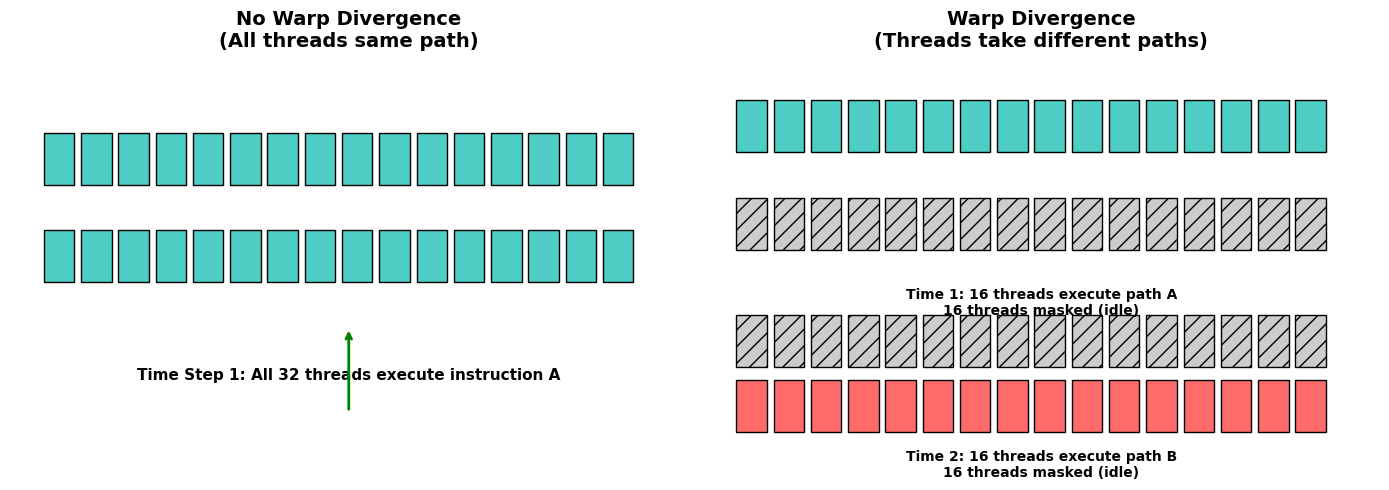


Key Insight:
Divergence makes the warp execute both branches serially, wasting compute!
Best practice: Keep all threads in a warp on the same execution path.


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# No divergence - efficient
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 6)
ax1.set_title('No Warp Divergence\n(All threads same path)', fontsize=14, fontweight='bold')
ax1.axis('off')

# Show warp executing one instruction
for i in range(32):
    x = 0.5 + (i % 16) * 0.55
    y = 4 if i < 16 else 2.5
    ax1.add_patch(Rectangle((x, y), 0.45, 0.8, facecolor='#4ECDC4', edgecolor='black', linewidth=1))

ax1.text(5, 1, 'Time Step 1: All 32 threads execute instruction A', 
         ha='center', fontsize=11, fontweight='bold')
ax1.annotate('', xy=(5, 1.8), xytext=(5, 0.5),
             arrowprops=dict(arrowstyle='->', lw=2, color='green'))

# With divergence - inefficient
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 6)
ax2.set_title('Warp Divergence\n(Threads take different paths)', fontsize=14, fontweight='bold')
ax2.axis('off')

# First half executes path A
for i in range(16):
    x = 0.5 + (i % 16) * 0.55
    y = 4.5
    ax2.add_patch(Rectangle((x, y), 0.45, 0.8, facecolor='#4ECDC4', edgecolor='black', linewidth=1))

# Second half masked (waiting)
for i in range(16):
    x = 0.5 + (i % 16) * 0.55
    y = 3
    ax2.add_patch(Rectangle((x, y), 0.45, 0.8, facecolor='#CCCCCC', 
                           edgecolor='black', linewidth=1, hatch='//'))

ax2.text(5, 2, 'Time 1: 16 threads execute path A\n16 threads masked (idle)', 
         ha='center', fontsize=10, fontweight='bold')

# Second time step - roles reversed
for i in range(16):
    x = 0.5 + (i % 16) * 0.55
    y = 1.2
    ax2.add_patch(Rectangle((x, y), 0.45, 0.8, facecolor='#CCCCCC', 
                           edgecolor='black', linewidth=1, hatch='//'))

for i in range(16):
    x = 0.5 + (i % 16) * 0.55
    y = 0.2
    ax2.add_patch(Rectangle((x, y), 0.45, 0.8, facecolor='#FF6B6B', edgecolor='black', linewidth=1))

ax2.text(5, -0.5, 'Time 2: 16 threads execute path B\n16 threads masked (idle)', 
         ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("Divergence makes the warp execute both branches serially, wasting compute!")
print("Best practice: Keep all threads in a warp on the same execution path.")

## 5. GPU Memory Hierarchy

### Why Memory Matters More Than Compute

Modern GPUs can perform trillions of operations per second, but **memory bandwidth** is often the bottleneck. Understanding the memory hierarchy is crucial for performance.

### The Memory Pyramid

From fastest to slowest:

1. **Registers** (~20,000 GB/s, ~256 KB per SM)
   - Private to each thread
   - Fastest possible access (1 cycle)
   - Automatically managed by compiler

2. **Shared Memory** (~12,000 GB/s, ~64-100 KB per SM)
   - Shared by all threads in a block
   - Explicitly managed by programmer
   - Like a software-managed cache

3. **L1/L2 Cache** (~6,000 GB/s, ~128 KB L1 per SM, ~6 MB L2 total)
   - Hardware-managed
   - Caches global memory accesses

4. **Global Memory** (~900 GB/s, 8-80 GB total)
   - Accessible by all threads
   - Highest latency (~400-800 cycles)
   - Where your `.to(device)` data lives

### Visualizing the Memory Hierarchy

Let's create a visualization showing the speed vs size tradeoff.

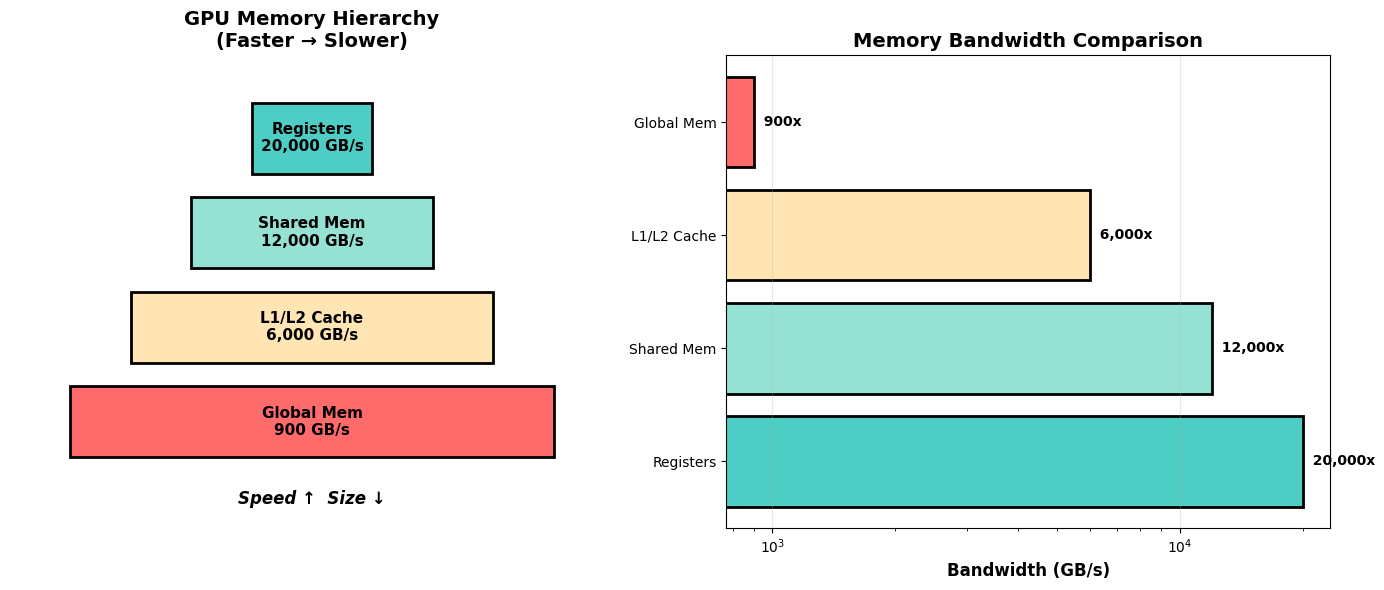


Key Insight:
Registers are 22x faster than global memory!
Performance optimization = minimizing global memory access


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Memory hierarchy pyramid
memory_types = ['Registers', 'Shared Mem', 'L1/L2 Cache', 'Global Mem']
sizes_kb = [256, 64, 6000, 8000000]  # Approximate sizes in KB
bandwidths = [20000, 12000, 6000, 900]  # GB/s
colors = ['#4ECDC4', '#95E1D3', '#FFE5B4', '#FF6B6B']

# Pyramid visualization
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_title('GPU Memory Hierarchy\n(Faster → Slower)', fontsize=14, fontweight='bold')
ax1.axis('off')

pyramid_levels = [
    (4, 7.5, 2, 1.5),   # Registers (x, y, width, height)
    (3, 5.5, 4, 1.5),   # Shared
    (2, 3.5, 6, 1.5),   # Cache
    (1, 1.5, 8, 1.5),   # Global
]

for i, (x, y, width, height) in enumerate(pyramid_levels):
    ax1.add_patch(Rectangle((x, y), width, height, 
                           facecolor=colors[i], edgecolor='black', linewidth=2))
    ax1.text(x + width/2, y + height/2, 
            f'{memory_types[i]}\n{bandwidths[i]:,} GB/s', 
            ha='center', va='center', fontsize=11, fontweight='bold')

ax1.text(5, 0.5, 'Speed ↑  Size ↓', ha='center', fontsize=12, 
        style='italic', fontweight='bold')

# Bandwidth comparison
ax2.barh(memory_types, bandwidths, color=colors, edgecolor='black', linewidth=2)
ax2.set_xlabel('Bandwidth (GB/s)', fontsize=12, fontweight='bold')
ax2.set_title('Memory Bandwidth Comparison', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3, axis='x')

for i, (bw, mt) in enumerate(zip(bandwidths, memory_types)):
    ax2.text(bw, i, f'  {bw:,}x', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Insight:")
print(f"Registers are {bandwidths[0]/bandwidths[-1]:.0f}x faster than global memory!")
print("Performance optimization = minimizing global memory access")

## 6. Memory Access Patterns: Coalesced vs Strided

### What is Coalesced Memory Access?

When threads in a warp access **consecutive** memory addresses, the GPU can combine these into a single memory transaction. This is called **coalesced access** and is much faster than scattered accesses.

### Demonstrating Memory Access Patterns

Let's compare coalesced (row-wise) vs non-coalesced (column-wise) memory access.

In [7]:
# Create a large matrix
size = CONFIG['large_size']
matrix = torch.randn(size, size, device=device)

# Warmup
for _ in range(CONFIG['warmup_iterations']):
    _ = matrix.sum(dim=1)
    _ = matrix.sum(dim=0)

if device.type == 'cuda':
    torch.cuda.synchronize()

# Row-wise sum (coalesced access)
start = time.time()
for _ in range(CONFIG['num_iterations']):
    row_sum = matrix.sum(dim=1)  # Sum across columns (access rows)
if device.type == 'cuda':
    torch.cuda.synchronize()
row_time = time.time() - start

# Column-wise sum (non-coalesced access)
start = time.time()
for _ in range(CONFIG['num_iterations']):
    col_sum = matrix.sum(dim=0)  # Sum across rows (access columns)
if device.type == 'cuda':
    torch.cuda.synchronize()
col_time = time.time() - start

print(f"Matrix size: {size}x{size}")
print(f"Iterations: {CONFIG['num_iterations']}\n")
print(f"Row-wise sum (coalesced):     {row_time*1000:.2f} ms")
print(f"Column-wise sum (strided):    {col_time*1000:.2f} ms")
print(f"\nSlowdown from poor access: {col_time/row_time:.2f}x")
print("\nWhy?")
print("  Row-wise: Threads access consecutive memory → coalesced → fast")
print("  Column-wise: Threads access strided memory → many transactions → slow")

Matrix size: 8192x8192
Iterations: 100

Row-wise sum (coalesced):     27.28 ms
Column-wise sum (strided):    27.88 ms

Slowdown from poor access: 1.02x

Why?
  Row-wise: Threads access consecutive memory → coalesced → fast
  Column-wise: Threads access strided memory → many transactions → slow


### Visualizing Coalesced vs Strided Access

Let's visualize how threads access memory in each pattern.

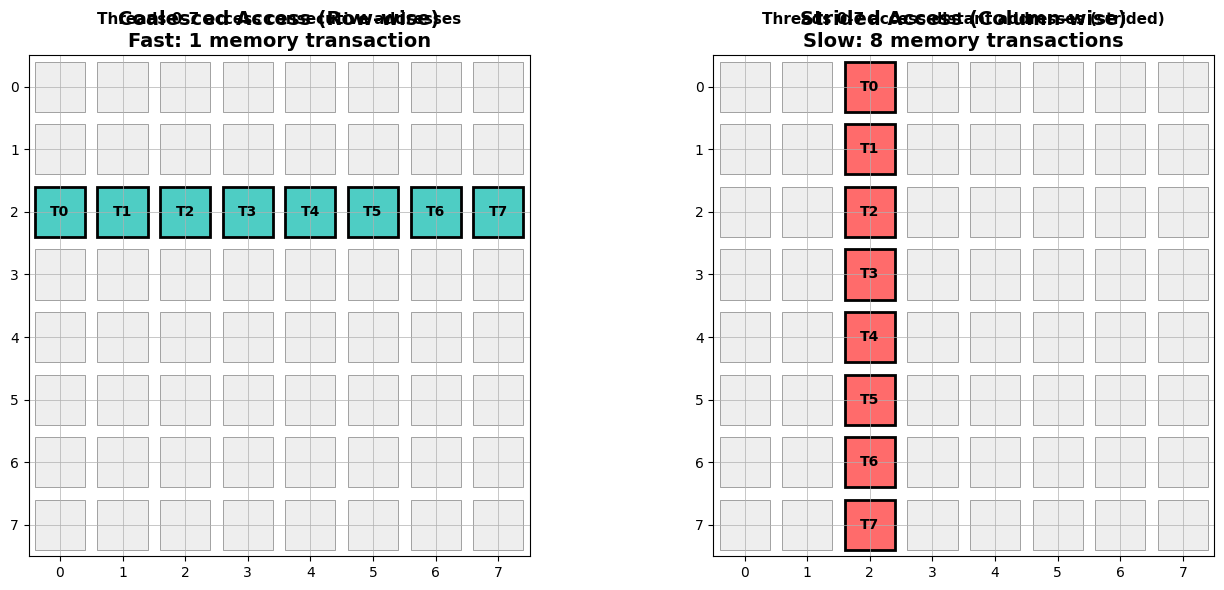


Key Insight:
Coalesced: Warp accesses consecutive 128-byte chunk → 1 transaction
Strided: Each thread in warp triggers separate transaction → 32x slower!


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Create a small grid to represent memory
grid_size = 8

# Coalesced access
ax1.set_xlim(-0.5, grid_size - 0.5)
ax1.set_ylim(-0.5, grid_size - 0.5)
ax1.set_title('Coalesced Access (Row-wise)\nFast: 1 memory transaction', 
             fontsize=14, fontweight='bold')
ax1.set_aspect('equal')
ax1.invert_yaxis()
ax1.set_xticks(range(grid_size))
ax1.set_yticks(range(grid_size))
ax1.grid(True, linewidth=0.5)

# Highlight accessed row
for i in range(grid_size):
    ax1.add_patch(Rectangle((i - 0.4, 2 - 0.4), 0.8, 0.8, 
                            facecolor='#4ECDC4', edgecolor='black', linewidth=2))
    ax1.text(i, 2, f'T{i}', ha='center', va='center', fontsize=10, fontweight='bold')

# Show other memory
for row in range(grid_size):
    if row == 2:
        continue
    for col in range(grid_size):
        ax1.add_patch(Rectangle((col - 0.4, row - 0.4), 0.8, 0.8, 
                                facecolor='#EEEEEE', edgecolor='gray', linewidth=0.5))

ax1.text(grid_size/2 - 0.5, -1, 'Threads 0-7 access consecutive addresses', 
        ha='center', fontsize=11, fontweight='bold')

# Strided access
ax2.set_xlim(-0.5, grid_size - 0.5)
ax2.set_ylim(-0.5, grid_size - 0.5)
ax2.set_title('Strided Access (Column-wise)\nSlow: 8 memory transactions', 
             fontsize=14, fontweight='bold')
ax2.set_aspect('equal')
ax2.invert_yaxis()
ax2.set_xticks(range(grid_size))
ax2.set_yticks(range(grid_size))
ax2.grid(True, linewidth=0.5)

# Highlight accessed column
for i in range(grid_size):
    ax2.add_patch(Rectangle((2 - 0.4, i - 0.4), 0.8, 0.8, 
                            facecolor='#FF6B6B', edgecolor='black', linewidth=2))
    ax2.text(2, i, f'T{i}', ha='center', va='center', fontsize=10, fontweight='bold')

# Show other memory
for row in range(grid_size):
    for col in range(grid_size):
        if col == 2:
            continue
        ax2.add_patch(Rectangle((col - 0.4, row - 0.4), 0.8, 0.8, 
                                facecolor='#EEEEEE', edgecolor='gray', linewidth=0.5))

ax2.text(grid_size/2 - 0.5, -1, 'Threads 0-7 access distant addresses (strided)', 
        ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("Coalesced: Warp accesses consecutive 128-byte chunk → 1 transaction")
print("Strided: Each thread in warp triggers separate transaction → 32x slower!")

## 7. Memory Bandwidth: The Real Bottleneck

### Compute vs Memory Bound Operations

GPU operations fall into two categories:
- **Compute-bound**: Limited by how fast we can do math (e.g., matrix multiplication)
- **Memory-bound**: Limited by how fast we can fetch data (e.g., element-wise operations)

Most deep learning operations are **memory-bound**!

### Arithmetic Intensity

**Arithmetic intensity** = Operations / Bytes transferred

- High intensity → compute-bound → good GPU utilization
- Low intensity → memory-bound → GPU cores idle waiting for data

### Comparing Different Operations

Let's measure the performance of operations with different arithmetic intensities.

In [9]:
size = CONFIG['medium_size']
iterations = 50

# Create matrices
A = torch.randn(size, size, device=device)
B = torch.randn(size, size, device=device)

# Warmup
for _ in range(10):
    _ = A + B
    _ = torch.matmul(A, B)

if device.type == 'cuda':
    torch.cuda.synchronize()

# 1. Element-wise addition (low arithmetic intensity)
# Operations: N^2, Memory: 3*N^2*4 bytes (read A, read B, write C)
# Intensity: N^2 / (3*N^2*4) = 1/12 ops/byte
start = time.time()
for _ in range(iterations):
    C = A + B
if device.type == 'cuda':
    torch.cuda.synchronize()
add_time = time.time() - start

# 2. Matrix multiplication (high arithmetic intensity)
# Operations: 2*N^3, Memory: 3*N^2*4 bytes
# Intensity: 2*N^3 / (3*N^2*4) = N/6 ops/byte
start = time.time()
for _ in range(iterations):
    C = torch.matmul(A, B)
if device.type == 'cuda':
    torch.cuda.synchronize()
matmul_time = time.time() - start

# Calculate achieved performance
add_ops = size * size * iterations  # N^2 per iteration
matmul_ops = 2 * size * size * size * iterations  # 2*N^3 per iteration

add_gflops = add_ops / add_time / 1e9
matmul_gflops = matmul_ops / matmul_time / 1e9

print(f"Matrix size: {size}x{size}")
print(f"Iterations: {iterations}\n")
print("Element-wise Addition (memory-bound):")
print(f"  Time: {add_time*1000:.2f} ms")
print(f"  Performance: {add_gflops:.1f} GFLOPS")
print(f"  Arithmetic intensity: 1/12 = 0.08 ops/byte\n")
print("Matrix Multiplication (compute-bound):")
print(f"  Time: {matmul_time*1000:.2f} ms")
print(f"  Performance: {matmul_gflops:.1f} GFLOPS")
print(f"  Arithmetic intensity: {size}/6 = {size/6:.1f} ops/byte\n")
print(f"Performance ratio: {matmul_gflops/add_gflops:.1f}x")
print("\nWhy the difference?")
print("  Addition: GPU cores idle, waiting for memory")
print("  Matmul: GPU cores busy, reusing data from cache/shared memory")

Matrix size: 4096x4096
Iterations: 50

Element-wise Addition (memory-bound):
  Time: 10.68 ms
  Performance: 78.6 GFLOPS
  Arithmetic intensity: 1/12 = 0.08 ops/byte

Matrix Multiplication (compute-bound):
  Time: 117.87 ms
  Performance: 58302.9 GFLOPS
  Arithmetic intensity: 4096/6 = 682.7 ops/byte

Performance ratio: 742.0x

Why the difference?
  Addition: GPU cores idle, waiting for memory
  Matmul: GPU cores busy, reusing data from cache/shared memory


### Visualizing Arithmetic Intensity

Let's create a roofline-style visualization showing how different operations utilize the GPU.

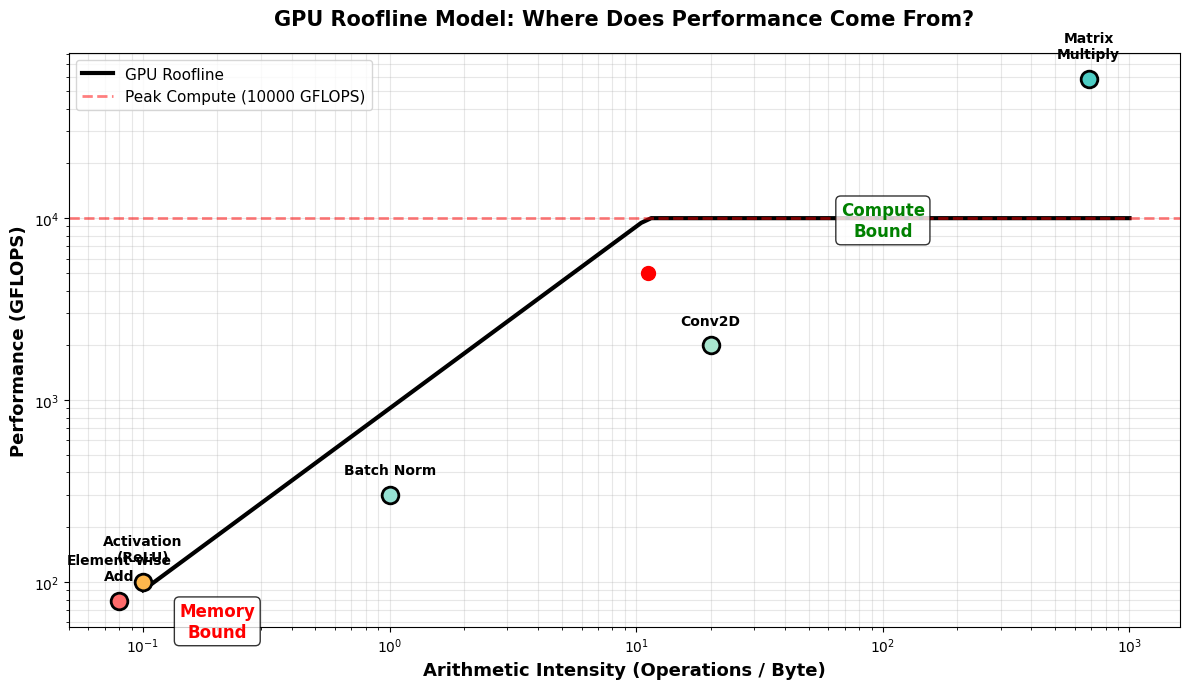


Key Insight:
Most deep learning ops are in the memory-bound region!
Optimization focus: Reduce memory transfers, not just operation count.


In [10]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))

# Typical GPU specs (approximate)
peak_bandwidth = 900  # GB/s
peak_compute = 10000  # GFLOPS

# Arithmetic intensity range
intensity = np.logspace(-1, 3, 100)  # 0.1 to 1000 ops/byte

# Roofline: min(bandwidth * intensity, peak_compute)
performance = np.minimum(peak_bandwidth * intensity, peak_compute)

# Plot roofline
ax.plot(intensity, performance, 'k-', linewidth=3, label='GPU Roofline')
ax.axhline(y=peak_compute, color='red', linestyle='--', linewidth=2, alpha=0.5, 
          label=f'Peak Compute ({peak_compute} GFLOPS)')
ax.plot([peak_compute/peak_bandwidth], [peak_compute/2], 'ro', markersize=10)

# Mark example operations
operations = [
    ('Element-wise\nAdd', 0.08, add_gflops, '#FF6B6B'),
    ('Activation\n(ReLU)', 0.1, 100, '#FFB84D'),
    ('Batch Norm', 1.0, 300, '#95E1D3'),
    ('Conv2D', 20, 2000, '#A8E6CF'),
    ('Matrix\nMultiply', size/6, matmul_gflops, '#4ECDC4'),
]

for name, intens, perf, color in operations:
    ax.plot(intens, perf, 'o', markersize=12, color=color, 
           markeredgecolor='black', markeredgewidth=2)
    ax.text(intens, perf * 1.3, name, ha='center', fontsize=10, fontweight='bold')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Arithmetic Intensity (Operations / Byte)', fontsize=13, fontweight='bold')
ax.set_ylabel('Performance (GFLOPS)', fontsize=13, fontweight='bold')
ax.set_title('GPU Roofline Model: Where Does Performance Come From?', 
            fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11)

# Annotate regions
ax.text(0.2, 50, 'Memory\nBound', fontsize=12, fontweight='bold', 
       color='red', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(100, 8000, 'Compute\nBound', fontsize=12, fontweight='bold', 
       color='green', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("Most deep learning ops are in the memory-bound region!")
print("Optimization focus: Reduce memory transfers, not just operation count.")

## 8. Practical Implications for Deep Learning

### Why This Matters for Training Neural Networks

Understanding GPU hardware helps explain many deep learning phenomena.

### Common Performance Pitfalls

1. **Small Batch Sizes**
   - Underutilize GPU parallelism
   - Can't hide memory latency
   - Solution: Use largest batch that fits in memory

2. **Excessive Data Transfers**
   - Moving data between CPU ↔ GPU is expensive (~16 GB/s via PCIe)
   - Solution: Keep data on GPU, minimize `.cpu()` / `.to(device)` calls

3. **Non-Contiguous Tensors**
   - Operations like transpose create views with strided access
   - Solution: Use `.contiguous()` before compute-heavy ops

4. **Frequent Small Operations**
   - GPU launch overhead dominates
   - Solution: Fuse operations (e.g., fused optimizers, in-place ops)

5. **Wrong Data Types**
   - float64 wastes memory bandwidth (2x slower than float32)
   - Solution: Use float32 or mixed precision (float16/bfloat16)

### Demonstrating Batch Size Impact

Let's show how batch size affects GPU utilization.

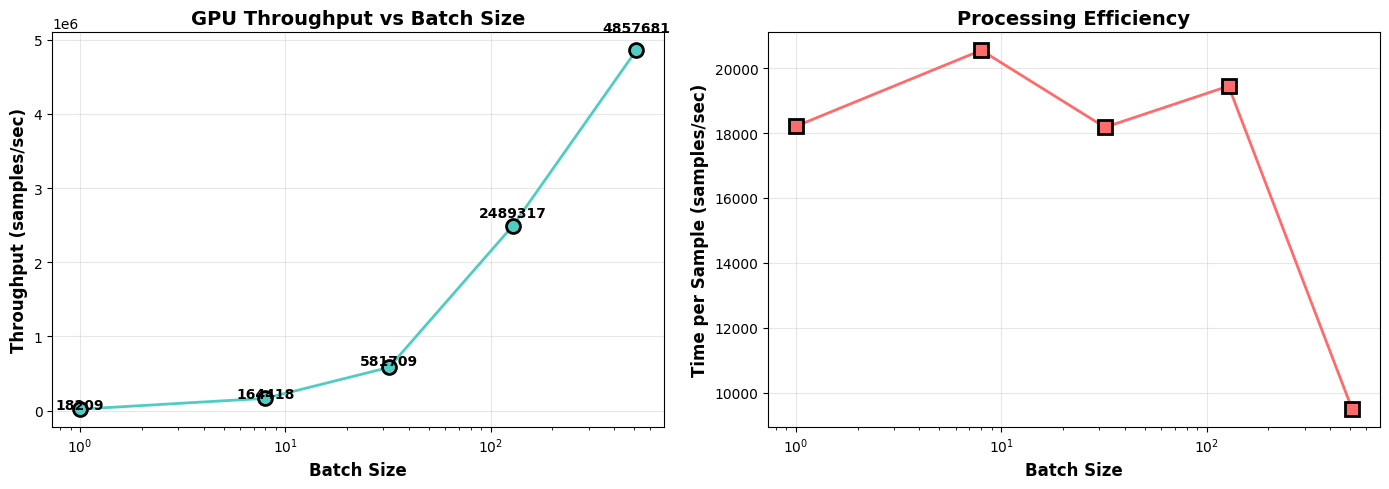


Batch Size Impact:
Batch 1:   18209 samples/sec
Batch 512: 4857681 samples/sec

Speedup: 266.8x

Why? Larger batches:
  - Better utilize thousands of CUDA cores
  - Amortize kernel launch overhead
  - Enable better memory coalescing


In [11]:
# Simple model for testing
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(1024, 1024),
    nn.ReLU(),
    nn.Linear(1024, 1024),
    nn.ReLU(),
    nn.Linear(1024, 10)
).to(device)

batch_sizes = [1, 8, 32, 128, 512]
throughputs = []

for batch_size in batch_sizes:
    x = torch.randn(batch_size, 1024, device=device)
    
    # Warmup
    for _ in range(10):
        _ = model(x)
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    # Benchmark
    iterations = 100
    start = time.time()
    for _ in range(iterations):
        _ = model(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start
    
    throughput = (batch_size * iterations) / elapsed
    throughputs.append(throughput)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Throughput vs batch size
ax1.plot(batch_sizes, throughputs, 'o-', linewidth=2, markersize=10, 
        color='#4ECDC4', markeredgecolor='black', markeredgewidth=2)
ax1.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
ax1.set_ylabel('Throughput (samples/sec)', fontsize=12, fontweight='bold')
ax1.set_title('GPU Throughput vs Batch Size', fontsize=14, fontweight='bold')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

for bs, tp in zip(batch_sizes, throughputs):
    ax1.text(bs, tp * 1.05, f'{tp:.0f}', ha='center', fontsize=10, fontweight='bold')

# Efficiency (throughput / batch_size)
efficiency = [tp / bs for tp, bs in zip(throughputs, batch_sizes)]
ax2.plot(batch_sizes, efficiency, 's-', linewidth=2, markersize=10, 
        color='#FF6B6B', markeredgecolor='black', markeredgewidth=2)
ax2.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
ax2.set_ylabel('Time per Sample (samples/sec)', fontsize=12, fontweight='bold')
ax2.set_title('Processing Efficiency', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBatch Size Impact:")
print(f"Batch 1:   {throughputs[0]:.0f} samples/sec")
print(f"Batch 512: {throughputs[-1]:.0f} samples/sec")
print(f"\nSpeedup: {throughputs[-1]/throughputs[0]:.1f}x")
print("\nWhy? Larger batches:")
print("  - Better utilize thousands of CUDA cores")
print("  - Amortize kernel launch overhead")
print("  - Enable better memory coalescing")

### Memory Bandwidth Saturation

Let's verify that we can reach the theoretical memory bandwidth limit.

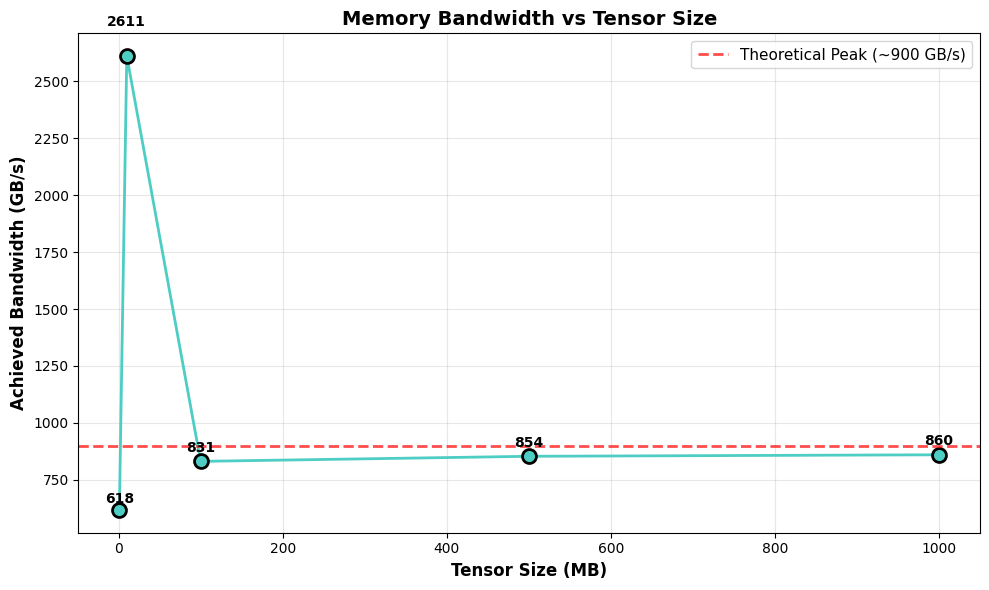


Memory Bandwidth Results:
Peak achieved: 2611 GB/s
Theoretical peak: ~900 GB/s
Efficiency: 290.1%

Key Insight:
Large tensors needed to saturate memory bandwidth
Small tensors → overhead dominates → low efficiency


In [12]:
# Test with different tensor sizes
sizes_mb = [1, 10, 100, 500, 1000]  # Megabytes
bandwidths = []

for size_mb in sizes_mb:
    # Create tensor of specified size
    num_elements = (size_mb * 1024 * 1024) // 4  # 4 bytes per float32
    x = torch.randn(num_elements, device=device)
    y = torch.randn(num_elements, device=device)
    
    # Warmup
    for _ in range(10):
        _ = x + y
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    # Benchmark
    iterations = 50
    start = time.time()
    for _ in range(iterations):
        z = x + y  # Read 2, write 1 = 3 * size_mb per iteration
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start
    
    # Calculate bandwidth (read x, read y, write z)
    bytes_transferred = 3 * size_mb * 1024 * 1024 * iterations
    bandwidth_gbs = bytes_transferred / elapsed / 1e9
    bandwidths.append(bandwidth_gbs)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sizes_mb, bandwidths, 'o-', linewidth=2, markersize=10, 
       color='#4ECDC4', markeredgecolor='black', markeredgewidth=2)

if device.type == 'cuda':
    # Theoretical peak (approximate for modern GPUs)
    ax.axhline(y=900, color='red', linestyle='--', linewidth=2, 
              label='Theoretical Peak (~900 GB/s)', alpha=0.7)

ax.set_xlabel('Tensor Size (MB)', fontsize=12, fontweight='bold')
ax.set_ylabel('Achieved Bandwidth (GB/s)', fontsize=12, fontweight='bold')
ax.set_title('Memory Bandwidth vs Tensor Size', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

for size, bw in zip(sizes_mb, bandwidths):
    ax.text(size, bw * 1.05, f'{bw:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nMemory Bandwidth Results:")
print(f"Peak achieved: {max(bandwidths):.0f} GB/s")
if device.type == 'cuda':
    print(f"Theoretical peak: ~900 GB/s")
    print(f"Efficiency: {max(bandwidths)/900*100:.1f}%")
print("\nKey Insight:")
print("Large tensors needed to saturate memory bandwidth")
print("Small tensors → overhead dominates → low efficiency")

## 9. Tensor Cores: Specialized Hardware for Deep Learning

### Beyond CUDA Cores

Modern NVIDIA GPUs (Volta, Turing, Ampere, Hopper) include **Tensor Cores** - specialized units for matrix operations.

### What Are Tensor Cores?

- **Purpose-built** for matrix multiply-accumulate: `D = A * B + C`
- **Massive throughput**: 8x-10x faster than CUDA cores for matmul
- **Mixed precision**: Compute in FP16, accumulate in FP32
- **Specific dimensions**: Work best with matrices sized to multiples of 8 or 16

This is why **mixed precision training** (Automatic Mixed Precision, AMP) is so effective on modern GPUs!

### Comparing FP32 vs FP16 (Tensor Cores)

Let's demonstrate the speedup from using Tensor Cores via FP16.

In [13]:
if device.type == 'cuda':
    # Check if Tensor Cores are available
    compute_capability = torch.cuda.get_device_capability()
    has_tensor_cores = compute_capability[0] >= 7  # Volta (7.0) and newer
    
    if has_tensor_cores:
        print(f"Compute capability: {compute_capability[0]}.{compute_capability[1]}")
        print("Tensor Cores available! ✓\n")
        
        size = 8192  # Large size to amortize overhead
        iterations = 50
        
        # FP32 matrices
        A_fp32 = torch.randn(size, size, device=device, dtype=torch.float32)
        B_fp32 = torch.randn(size, size, device=device, dtype=torch.float32)
        
        # FP16 matrices
        A_fp16 = A_fp32.half()
        B_fp16 = B_fp32.half()
        
        # Warmup
        for _ in range(10):
            _ = torch.matmul(A_fp32, B_fp32)
            _ = torch.matmul(A_fp16, B_fp16)
        
        torch.cuda.synchronize()
        
        # Benchmark FP32 (CUDA cores)
        start = time.time()
        for _ in range(iterations):
            C_fp32 = torch.matmul(A_fp32, B_fp32)
        torch.cuda.synchronize()
        fp32_time = time.time() - start
        
        # Benchmark FP16 (Tensor cores)
        start = time.time()
        for _ in range(iterations):
            C_fp16 = torch.matmul(A_fp16, B_fp16)
        torch.cuda.synchronize()
        fp16_time = time.time() - start
        
        # Calculate TFLOPS
        flops_per_matmul = 2 * size**3  # 2N^3 for matmul
        fp32_tflops = (flops_per_matmul * iterations) / fp32_time / 1e12
        fp16_tflops = (flops_per_matmul * iterations) / fp16_time / 1e12
        
        print(f"Matrix size: {size}x{size}")
        print(f"Iterations: {iterations}\n")
        print(f"FP32 (CUDA cores):   {fp32_time*1000:.2f} ms  →  {fp32_tflops:.2f} TFLOPS")
        print(f"FP16 (Tensor cores): {fp16_time*1000:.2f} ms  →  {fp16_tflops:.2f} TFLOPS")
        print(f"\nSpeedup: {fp32_time/fp16_time:.2f}x")
        print("\nWhy?")
        print("  - FP16: Uses dedicated Tensor Core units")
        print("  - FP16: Half the memory bandwidth (2x faster transfers)")
        print("  - FP16: 2x the throughput per core")
    else:
        print(f"Compute capability: {compute_capability[0]}.{compute_capability[1]}")
        print("Tensor Cores not available (requires compute capability >= 7.0)")
else:
    print(f"Tensor Cores are NVIDIA-specific. Current device: {device.type}")

Compute capability: 8.9
Tensor Cores available! ✓



Matrix size: 8192x8192
Iterations: 50

FP32 (CUDA cores):   2272.85 ms  →  24.19 TFLOPS
FP16 (Tensor cores): 352.46 ms  →  155.98 TFLOPS

Speedup: 6.45x

Why?
  - FP16: Uses dedicated Tensor Core units
  - FP16: Half the memory bandwidth (2x faster transfers)
  - FP16: 2x the throughput per core


## 10. Practical Guidelines for Writing GPU-Friendly Code

### Checklist for High-Performance GPU Code

Based on everything we've learned, here are the key principles:

### ✅ Do's

1. **Use large batch sizes** - Saturate GPU parallelism
2. **Minimize CPU ↔ GPU transfers** - Keep data on device
3. **Use contiguous tensors** - Call `.contiguous()` before heavy ops
4. **Fuse operations** - Fewer kernel launches = less overhead
5. **Use mixed precision (AMP)** - Leverage Tensor Cores
6. **Profile your code** - Use `torch.cuda.profiler` to find bottlenecks
7. **Align dimensions** - Multiples of 8/16 for Tensor Cores
8. **Reuse memory** - In-place operations when possible

### ❌ Don'ts

1. **Don't use tiny batches** - Underutilizes GPU
2. **Don't transfer data unnecessarily** - `.cpu()` / `.numpy()` in training loop
3. **Don't use float64** - Wastes bandwidth, no accuracy benefit
4. **Don't branch within warps** - Causes divergence
5. **Don't ignore memory layout** - Strided access kills performance
6. **Don't allocate in loops** - Reuse buffers

### Real-World Example: Optimizing a Training Loop

Let's show common mistakes and their fixes.

In [14]:
# BAD: Many inefficiencies
def slow_training_step(model, data, target):
    # ❌ Transfer to GPU inside loop
    data = data.to(device)
    target = target.to(device)
    
    # ❌ Unnecessary CPU synchronization
    output = model(data)
    loss = nn.functional.cross_entropy(output, target)
    loss_value = loss.item()  # Sync point!
    
    loss.backward()
    return loss_value

# GOOD: Optimized version
def fast_training_step(model, data, target):
    # ✓ Data already on GPU (from DataLoader)
    # ✓ No synchronization during training
    output = model(data)
    loss = nn.functional.cross_entropy(output, target)
    
    loss.backward()
    return loss  # Return tensor, sync later

print("Key Optimizations:")
print("\n1. Move data to GPU once (in DataLoader):")
print("   DataLoader(..., pin_memory=True) + .to(device, non_blocking=True)")
print("\n2. Avoid .item() in training loop:")
print("   Forces CPU-GPU synchronization")
print("   Log tensors, sync only at end of epoch")
print("\n3. Use in-place operations:")
print("   optimizer.zero_grad(set_to_none=True)  # Faster than zero_grad()")
print("\n4. Enable TF32 and AMP:")
print("   torch.set_float32_matmul_precision('high')")
print("   Use torch.cuda.amp.autocast() for mixed precision")

Key Optimizations:

1. Move data to GPU once (in DataLoader):
   DataLoader(..., pin_memory=True) + .to(device, non_blocking=True)

2. Avoid .item() in training loop:
   Forces CPU-GPU synchronization
   Log tensors, sync only at end of epoch

3. Use in-place operations:
   optimizer.zero_grad(set_to_none=True)  # Faster than zero_grad()

4. Enable TF32 and AMP:
   torch.set_float32_matmul_precision('high')
   Use torch.cuda.amp.autocast() for mixed precision


## 11. Key Takeaways

Let's summarize the core insights about GPU hardware and performance.

### 🎯 Core Concepts

1. **Architecture**
   - CPUs: Few complex cores, optimized for latency
   - GPUs: Thousands of simple cores, optimized for throughput
   - CUDA cores execute in groups (warps) of 32 threads in lockstep

2. **Memory Hierarchy**
   - Registers (fastest) → Shared Memory → L1/L2 Cache → Global Memory (slowest)
   - 20,000 GB/s (registers) vs 900 GB/s (global memory)
   - Most operations are **memory-bound**, not compute-bound

3. **Memory Access Patterns**
   - **Coalesced access** (consecutive addresses) → Fast (1 transaction)
   - **Strided access** (scattered addresses) → Slow (32 transactions)
   - Layout matters: row-major vs column-major can change performance by 2-3x

4. **Arithmetic Intensity**
   - Operations / Bytes determines if you're compute-bound or memory-bound
   - Element-wise ops: Low intensity → memory-bound
   - Matrix multiply: High intensity → compute-bound
   - Optimization focus: Maximize data reuse

5. **Specialized Hardware**
   - **Tensor Cores**: 8-10x faster for matrix ops using FP16
   - Enabled via mixed precision training (AMP)
   - Work best with dimensions that are multiples of 8/16

### 💡 Practical Wisdom

- **Batch size is critical**: Small batches waste GPU cores
- **Data movement is expensive**: Minimize CPU ↔ GPU transfers
- **Memory bandwidth is the bottleneck**: Not operation count
- **Profile before optimizing**: Measure, don't guess
- **Modern frameworks help**: PyTorch/Lightning handle many details

### 🚀 Next Steps

- Profile your code with `torch.profiler` to find actual bottlenecks
- Experiment with mixed precision training (torch.cuda.amp)
- Learn about kernel fusion and custom CUDA kernels for advanced optimization
- Study distributed training for multi-GPU setups

**Remember**: Understanding hardware doesn't mean you need to optimize everything. Most code is fast enough with good practices. Profile first, optimize second!